# 💳 Financial Fraud & Transaction Risk Intelligence

## Project Overview

This project develops an end-to-end transaction fraud detection and risk
scoring workflow for financial transactions.

The objective is not only to classify transactions as fraudulent or
legitimate, but to support operational decision making by balancing fraud
detection performance against false-positive risk.

## Business Problem

Financial institutions and payment platforms must detect suspicious
transactions while minimizing disruption to legitimate customers.

Two errors have different business consequences:

- **False Negative:** fraudulent transaction is missed, creating potential
  financial loss.
- **False Positive:** legitimate transaction is flagged, potentially creating
  customer friction and unnecessary investigation workload.

The project therefore focuses on:

> **Detecting as much fraud as possible while maintaining an operationally
> acceptable false-positive rate.**

## Key Business Questions

1. How severe is fraud prevalence in the transaction population?
2. Which transaction types are most associated with fraud?
3. What transaction characteristics distinguish fraudulent behavior?
4. How severe is the class imbalance?
5. Which classification model performs best under imbalanced conditions?
6. What threshold provides the best operational trade-off?
7. How many fraudulent transactions can be captured?
8. What potential transaction value is associated with detected and missed fraud?
9. How can the model output be translated into an operational risk score?

## Analytical Workflow

Business Problem
→ Data Audit
→ Fraud Distribution
→ Exploratory Analysis
→ Feature Engineering
→ Leakage Audit
→ Time-Aware Train/Validation/Test Split
→ Baseline Model
→ Imbalanced Classification
→ Precision-Recall Evaluation
→ Threshold Optimization
→ Financial Exposure Analysis
→ Explainable Risk Scoring
→ Streamlit Fraud Operations Center

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = Path("../data/raw/paysim.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)

df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.6400",C1231006815,"170,136.0000","160,296.3600",M1979787155,0.0000,0.0000,0,0
1,1,PAYMENT,"1,864.2800",C1666544295,"21,249.0000","19,384.7200",M2044282225,0.0000,0.0000,0,0
2,1,TRANSFER,181.0000,C1305486145,181.0000,0.0000,C553264065,0.0000,0.0000,1,0
3,1,CASH_OUT,181.0000,C840083671,181.0000,0.0000,C38997010,"21,182.0000",0.0000,1,0
4,1,PAYMENT,"11,668.1400",C2048537720,"41,554.0000","29,885.8600",M1230701703,0.0000,0.0000,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("Missing_Count")
)

missing_summary["Missing_Percentage"] = (
    missing_summary["Missing_Count"]
    / len(df)
    * 100
)

missing_summary.sort_values(
    "Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
step,0,0.0000
type,0,0.0000
amount,0,0.0000
nameOrig,0,0.0000
oldbalanceOrg,0,0.0000
newbalanceOrig,0,0.0000
nameDest,0,0.0000
oldbalanceDest,0,0.0000
newbalanceDest,0,0.0000
isFraud,0,0.0000


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
fraud_rate = df["isFraud"].mean()

print(f"Fraud rate: {fraud_rate:.4%}")

Fraud rate: 0.1291%


In [8]:
df["amount"].describe()

count    6,362,620.0000
mean       179,861.9035
std        603,858.2315
min              0.0000
25%         13,389.5700
50%         74,871.9400
75%        208,721.4775
max     92,445,516.6400
Name: amount, dtype: float64

In [9]:
df.groupby("isFraud")["amount"].agg(
    ["count", "mean", "median", "sum"]
)

,count,mean,median,sum
isFraud,,,,
0,6354407,"178,197.0417","74,684.7200","1,132,336,529,331.9299"
1,8213,"1,467,967.2991","441,423.4400","12,056,415,427.8400"


In [10]:
total_transactions = len(df)

fraud_transactions = int(
    df["isFraud"].sum()
)

fraud_rate = (
    fraud_transactions
    / total_transactions
)

total_value = df["amount"].sum()

fraud_value = (
    df.loc[df["isFraud"] == 1, "amount"]
    .sum()
)

print("Total transactions :", f"{total_transactions:,}")
print("Fraud transactions :", f"{fraud_transactions:,}")
print("Fraud rate         :", f"{fraud_rate:.4%}")
print("Total value        :", f"{total_value:,.2f}")
print("Fraud value        :", f"{fraud_value:,.2f}")

Total transactions : 6,362,620
Fraud transactions : 8,213
Fraud rate         : 0.1291%
Total value        : 1,144,392,944,759.77
Fraud value        : 12,056,415,427.84


In [11]:
fraud_by_type = (
    df.groupby("type")
    .agg(
        Transactions=("isFraud", "count"),
        Fraud_Count=("isFraud", "sum"),
        Transaction_Value=("amount", "sum"),
        Fraud_Value=("amount", lambda x: 0)
    )
    .reset_index()
)

In [12]:
fraud_by_type = (
    df.assign(
        fraud_value=np.where(
            df["isFraud"] == 1,
            df["amount"],
            0
        )
    )
    .groupby("type")
    .agg(
        Transactions=("isFraud", "count"),
        Fraud_Count=("isFraud", "sum"),
        Transaction_Value=("amount", "sum"),
        Fraud_Value=("fraud_value", "sum")
    )
    .reset_index()
)

fraud_by_type["Fraud_Rate"] = (
    fraud_by_type["Fraud_Count"]
    / fraud_by_type["Transactions"]
)

fraud_by_type.sort_values(
    "Fraud_Rate",
    ascending=False
)

,type,Transactions,Fraud_Count,Transaction_Value,Fraud_Value,Fraud_Rate
4,TRANSFER,532909,4097,"485,291,987,263.1700","6,067,213,184.0100",0.0077
1,CASH_OUT,2237500,4116,"394,412,995,224.4900","5,989,202,243.8300",0.0018
0,CASH_IN,1399284,0,"236,367,391,912.4600",0.0000,0.0000
2,DEBIT,41432,0,"227,199,221.2800",0.0000,0.0000
3,PAYMENT,2151495,0,"28,093,371,138.3700",0.0000,0.0000


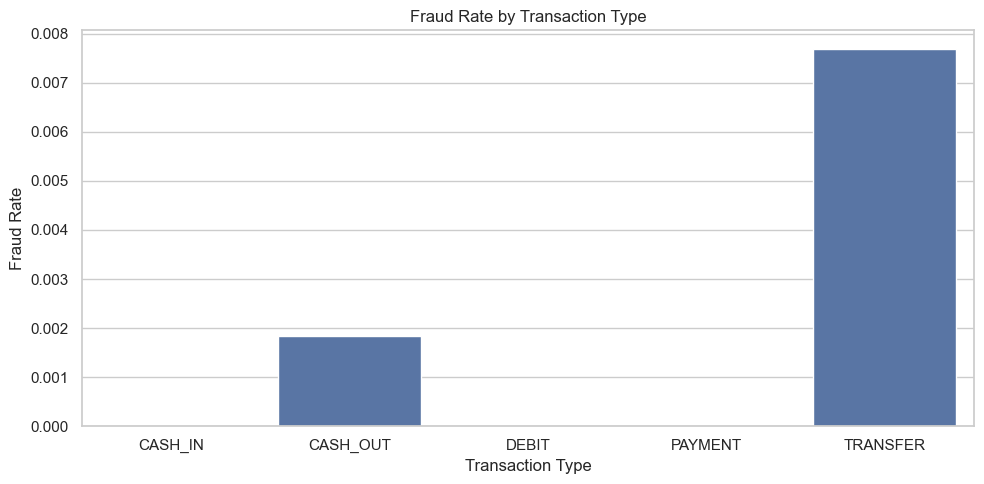

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=fraud_by_type,
    x="type",
    y="Fraud_Rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")

plt.tight_layout()
plt.show()

## 4. Exploratory Fraud Analysis — Initial Findings

### Fraud Prevalence

The dataset contains **6,362,620 transactions**, of which only **8,213**
are labeled as fraudulent.

This corresponds to a fraud rate of approximately **0.1291%**, indicating a
severely imbalanced classification problem.

The low prevalence of fraud means that accuracy alone would be misleading.
The project therefore prioritizes precision, recall, F1-score, PR-AUC, and
threshold analysis.

### Financial Exposure

The dataset contains approximately **1.144 trillion** in total transaction
value.

Fraudulent transactions account for approximately **12.06 billion** in
transaction value.

This demonstrates that even a very small proportion of fraudulent
transactions can represent substantial financial exposure.

### Fraud Concentration by Transaction Type

Fraud is highly concentrated in two transaction types:

- **TRANSFER:** 4,097 fraud transactions and approximately 0.77% fraud rate.
- **CASH_OUT:** 4,116 fraud transactions and approximately 0.18% fraud rate.

No fraud observations were identified in the observed CASH_IN, DEBIT, or
PAYMENT groups.

Together, TRANSFER and CASH_OUT account for all observed fraudulent
transactions in the dataset.

### Business Insight

The concentration of fraud in transfer and cash-out activity suggests that
these transaction types may deserve greater monitoring priority in a
risk-scoring workflow.

However, the observed association should not be interpreted as causal
evidence that a particular transaction type causes fraud.

In [14]:
balance_analysis = df.groupby("isFraud").agg(
    avg_oldbalance_org=("oldbalanceOrg", "mean"),
    avg_newbalance_orig=("newbalanceOrig", "mean"),
    avg_oldbalance_dest=("oldbalanceDest", "mean"),
    avg_newbalance_dest=("newbalanceDest", "mean"),
    avg_amount=("amount", "mean")
)

balance_analysis

,avg_oldbalance_org,avg_newbalance_orig,avg_oldbalance_dest,avg_newbalance_dest,avg_amount
isFraud,,,,,
0,"832,828.7117","855,970.2281","1,101,420.8746","1,224,925.6846","178,197.0417"
1,"1,649,667.6057","192,392.6318","544,249.6191","1,279,707.6171","1,467,967.2991"


In [15]:
df["origin_balance_change"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
)

df["destination_balance_change"] = (
    df["newbalanceDest"]
    - df["oldbalanceDest"]
)

In [16]:
balance_behavior = df.groupby("isFraud").agg(
    origin_change_mean=("origin_balance_change", "mean"),
    origin_change_median=("origin_balance_change", "median"),
    destination_change_mean=("destination_balance_change", "mean"),
    destination_change_median=("destination_balance_change", "median")
)

balance_behavior

,origin_change_mean,origin_change_median,destination_change_mean,destination_change_median
isFraud,,,,
0,"-23,141.5164",0.0000,"123,504.8100",0.0000
1,"1,457,274.9739","436,317.4900","735,457.9981",0.0000


In [17]:
fraud_type_behavior = (
    df[df["isFraud"] == 1]
    .groupby("type")
    .agg(
        fraud_count=("isFraud", "count"),
        avg_amount=("amount", "mean"),
        avg_origin_change=("origin_balance_change", "mean"),
        avg_destination_change=("destination_balance_change", "mean")
    )
    .reset_index()
)

fraud_type_behavior

,type,fraud_count,avg_amount,avg_origin_change,avg_destination_change
0,CASH_OUT,4116,"1,455,102.5860","1,453,796.4607","1,464,626.4212"
1,TRANSFER,4097,"1,480,891.6729","1,460,769.6188","2,908.0274"


## 5. Transaction Behavior Analysis

### Transaction Value

Fraudulent transactions have substantially higher average transaction values
than legitimate transactions.

- Legitimate transactions: approximately **178K**
- Fraudulent transactions: approximately **1.47M**

This indicates that transaction value is an important risk signal, although
amount alone should not be treated as sufficient evidence of fraud.

### Origin Balance Movement

The difference in origin-account balance movement is substantial.

For legitimate transactions, the mean origin balance change is approximately
**-23K**, while fraudulent transactions show an average change of approximately
**1.46M**.

This suggests that fraudulent activity is associated with unusually large
depletion of the originating account balance.

### Transaction-Type Behavior

Fraudulent CASH_OUT and TRANSFER transactions exhibit different balance
patterns.

CASH_OUT transactions show large changes in both origin and destination
balances, while fraudulent TRANSFER transactions show large origin-account
depletion but comparatively small destination balance changes.

This indicates that fraud detection should consider combinations of:

- Transaction type
- Transaction amount
- Origin balance behavior
- Destination balance behavior

rather than relying on a single variable.

### Business Insight

The observed patterns support a transaction risk-scoring approach in which
large transaction values and abnormal balance movements contribute to
investigation priority.

These relationships are observational and should not be interpreted as
causal evidence.

In [18]:
df["amount_to_oldbalance_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    df["amount"] / df["oldbalanceOrg"],
    0
)

df["origin_balance_drop"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["destination_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

df["amount_to_newbalance_ratio"] = np.where(
    df["newbalanceOrig"] > 0,
    df["amount"] / df["newbalanceOrig"],
    0
)

In [19]:
feature_behavior = df.groupby("isFraud").agg(
    amount_mean=("amount", "mean"),
    origin_drop_mean=("origin_balance_drop", "mean"),
    amount_to_old_ratio_mean=("amount_to_oldbalance_ratio", "mean"),
    amount_to_new_ratio_mean=("amount_to_newbalance_ratio", "mean"),
)

feature_behavior

,amount_mean,origin_drop_mean,amount_to_old_ratio_mean,amount_to_new_ratio_mean
isFraud,,,,
0,"178,197.0417","-23,141.5164",81.8178,0.8484
1,"1,467,967.2991","1,457,274.9739",0.9938,0.0700


In [20]:
df["balance_inconsistency"] = (
    df["oldbalanceOrg"]
    - df["newbalanceOrig"]
    - df["amount"]
)

In [21]:
df["balance_inconsistency"].describe()

count     6,362,620.0000
mean       -201,092.4681
std         606,650.4601
min     -92,445,516.6400
25%        -249,641.0875
50%         -68,677.2550
75%          -2,954.2300
max               0.0100
Name: balance_inconsistency, dtype: float64

In [22]:
df.groupby("isFraud")["balance_inconsistency"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

,count,mean,median,std,min,max
isFraud,,,,,,
0,6354407,"-201,338.5581","-69,049.3100","606,928.8908","-92,445,516.6400",0.0100
1,8213,"-10,692.3253",0.0000,"265,146.1311","-10,000,000.0000",0.0000


In [23]:
np.mean(
    np.isclose(
        df["balance_inconsistency"],
        0,
        atol=1e-6
    )
)

np.float64(0.19442745284175386)

In [24]:
df.groupby("isFraud")["balance_inconsistency"].apply(
    lambda x: np.mean(np.isclose(x, 0, atol=1e-6))
)

isFraud
0   0.1934
1   0.9945
Name: balance_inconsistency, dtype: float64

In [25]:
df["amount_to_oldbalance_ratio"] = np.where(
    df["oldbalanceOrg"] > 0,
    np.minimum(
        df["amount"] / df["oldbalanceOrg"],
        10
    ),
    0
)

In [26]:
df.groupby("isFraud")["amount_to_oldbalance_ratio"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
isFraud,,,,
0,2.1230,0.0761,0.0000,10.0000
1,0.9902,1.0000,0.0000,10.0000


In [27]:
model_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_drop",
    "destination_balance_change",
    "amount_to_oldbalance_ratio",
]

X = df[model_features].copy()
y = df["isFraud"].copy()

In [28]:
split_point = int(len(df) * 0.80)

X_train = X.iloc[:split_point].copy()
X_test = X.iloc[split_point:].copy()

y_train = y.iloc[:split_point].copy()
y_test = y.iloc[split_point:].copy()

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (5090096, 10)
Test : (1272524, 10)


In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

categorical_features = ["type"]

numeric_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "origin_balance_drop",
    "destination_balance_change",
    "amount_to_oldbalance_ratio",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            n_jobs=-1
        )
    )
])

In [30]:
logistic_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [31]:
y_prob = logistic_model.predict_proba(
    X_test
)[:, 1]

baseline_pred = (
    y_prob >= 0.5
).astype(int)

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        baseline_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        y_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        y_prob
    )
}

baseline_metrics

{'Accuracy': 0.9753788533654375,
 'Precision': 0.10883823062032302,
 'Recall': 0.885519511048425,
 'F1': 0.193850508169304,
 'ROC_AUC': 0.9858057132485212,
 'PR_AUC': 0.6775139808720905}

In [32]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

threshold_df = pd.DataFrame({
    "threshold": thresholds,
    "precision": precision[:-1],
    "recall": recall[:-1],
})

threshold_df["f1"] = (
    2
    * threshold_df["precision"]
    * threshold_df["recall"]
    / (
        threshold_df["precision"]
        + threshold_df["recall"]
        + 1e-9
    )
)

In [33]:
best_f1_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

best_f1_row

threshold   0.9898
precision   0.8035
recall      0.5393
f1          0.6454
Name: 1269601, dtype: float64

In [34]:
precision_30 = threshold_df[
    threshold_df["precision"] >= 0.30
]

precision_30.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall,f1
1261723,0.7993,0.3000,0.7569,0.4297
1261724,0.7993,0.3000,0.7569,0.4297
1261725,0.7993,0.3001,0.7569,0.4298
1261726,0.7993,0.3001,0.7569,0.4298
1261727,0.7994,0.3001,0.7569,0.4298
1261728,0.7994,0.3001,0.7569,0.4298
1261729,0.7994,0.3002,0.7569,0.4299
1261730,0.7995,0.3002,0.7569,0.4299
1261731,0.7996,0.3002,0.7569,0.4299
1261732,0.7996,0.3003,0.7569,0.4300


In [35]:
precision_50 = threshold_df[
    threshold_df["precision"] >= 0.50
]

precision_50.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall,f1
1266788,0.9197,0.5000,0.6662,0.5713
1266789,0.9197,0.5001,0.6662,0.5713
1266790,0.9197,0.5002,0.6662,0.5714
1266791,0.9198,0.5003,0.6662,0.5714
1266792,0.9198,0.5004,0.6662,0.5715
1266793,0.9198,0.5004,0.6662,0.5715
1266794,0.9199,0.5005,0.6662,0.5716
1266795,0.9199,0.5006,0.6662,0.5717
1266796,0.9199,0.5007,0.6662,0.5717
1266797,0.9199,0.5008,0.6662,0.5718


In [36]:
def threshold_summary(
    y_true,
    y_prob,
    threshold
):
    pred = (y_prob >= threshold).astype(int)

    tp = ((y_true == 1) & (pred == 1)).sum()
    fp = ((y_true == 0) & (pred == 1)).sum()
    tn = ((y_true == 0) & (pred == 0)).sum()
    fn = ((y_true == 1) & (pred == 0)).sum()

    precision = precision_score(
        y_true,
        pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        pred,
        zero_division=0
    )

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn
    }

In [37]:
candidate_thresholds = [
    0.30,
    0.50,
    float(best_f1_row["threshold"])
]

In [38]:
threshold_results = pd.DataFrame([
    threshold_summary(
        y_test,
        y_prob,
        threshold
    )
    for threshold in candidate_thresholds
])

threshold_results

,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.3000,0.0495,0.9441,0.0940,4016,77177,1191093,238
1,0.5000,0.1088,0.8855,0.1939,3767,30844,1237426,487
2,0.9898,0.8035,0.5393,0.6454,2294,561,1267709,1960


In [39]:
test_amount = df.iloc[split_point:]["amount"].reset_index(drop=True)

threshold_financial = []

for threshold in [0.30, 0.50, 0.9898]:

    pred = (y_prob >= threshold).astype(int)

    detected_fraud_value = test_amount[
        (y_test.reset_index(drop=True) == 1) &
        (pred == 1)
    ].sum()

    missed_fraud_value = test_amount[
        (y_test.reset_index(drop=True) == 1) &
        (pred == 0)
    ].sum()

    flagged_value = test_amount[
        pred == 1
    ].sum()

    threshold_financial.append({
        "Threshold": threshold,
        "Detected_Fraud_Value": detected_fraud_value,
        "Missed_Fraud_Value": missed_fraud_value,
        "Flagged_Transaction_Value": flagged_value
    })

financial_thresholds = pd.DataFrame(threshold_financial)

financial_thresholds

,Threshold,Detected_Fraud_Value,Missed_Fraud_Value,Flagged_Transaction_Value
0,0.3000,"6,505,447,728.2900","179,285,517.5300","15,062,096,690.1800"
1,0.5000,"6,487,197,039.2700","197,536,206.5500","11,782,324,772.1000"
2,0.9898,"6,206,089,057.5000","478,644,188.3200","6,525,541,745.1400"


In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

rf_pred = (
    rf_prob >= 0.5
).astype(int)

In [42]:
rf_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        rf_pred
    ),
    "Precision": precision_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_prob
    ),
    "PR_AUC": average_precision_score(
        y_test,
        rf_prob
    )
}

rf_metrics

{'Accuracy': 0.9999984283204089,
 'Precision': 1.0,
 'Recall': 0.999529854254819,
 'F1': 0.999764871855161,
 'ROC_AUC': 0.9999999994439522,
 'PR_AUC': 0.9999998343390609}

In [43]:
model_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **baseline_metrics
    },
    {
        "Model": "Random Forest",
        **rf_metrics
    }
])

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9754,0.1088,0.8855,0.1939,0.9858,0.6775
1,Random Forest,1.0000,1.0000,0.9995,0.9998,1.0000,1.0000


In [44]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_test,
    rf_prob
)

rf_threshold_df = pd.DataFrame({
    "threshold": thresholds_rf,
    "precision": precision_rf[:-1],
    "recall": recall_rf[:-1],
})

rf_threshold_df["f1"] = (
    2
    * rf_threshold_df["precision"]
    * rf_threshold_df["recall"]
    / (
        rf_threshold_df["precision"]
        + rf_threshold_df["recall"]
        + 1e-9
    )
)

In [45]:
best_rf_f1 = rf_threshold_df.loc[
    rf_threshold_df["f1"].idxmax()
]

best_rf_f1

threshold   0.4980
precision   1.0000
recall      0.9998
f1          0.9999
Name: 15280, dtype: float64

In [46]:
rf_precision_80 = rf_threshold_df[
    rf_threshold_df["precision"] >= 0.80
].copy()

rf_precision_80.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall,f1
14870,0.0998,0.8001,1.0000,0.8889
14871,0.0998,0.8002,1.0000,0.8890
14872,0.0998,0.8007,1.0000,0.8893
14873,0.0999,0.8010,1.0000,0.8895
14874,0.0999,0.8011,1.0000,0.8896
14875,0.1000,0.8016,1.0000,0.8899
14876,0.1000,0.8020,1.0000,0.8901
14877,0.1000,0.8022,1.0000,0.8902
14878,0.1000,0.8028,1.0000,0.8906
14879,0.1001,0.8032,1.0000,0.8909


In [47]:
threshold_candidates = [
    0.30,
    0.50,
    float(best_rf_f1["threshold"])
]

In [48]:
rf_threshold_summary = pd.DataFrame([
    threshold_summary(
        y_test,
        rf_prob,
        threshold
    )
    for threshold in threshold_candidates
])

rf_threshold_summary

,threshold,precision,recall,f1,TP,FP,TN,FN
0,0.3000,1.0000,0.9998,0.9999,4253,0,1268270,1
1,0.5000,1.0000,0.9995,0.9998,4252,0,1268270,2
2,0.4980,1.0000,0.9998,0.9999,4253,0,1268270,1


In [49]:
test_amount = (
    df.iloc[split_point:]["amount"]
    .reset_index(drop=True)
)

rf_financial = []

for threshold in threshold_candidates:

    pred = (
        rf_prob >= threshold
    ).astype(int)

    detected_fraud_value = test_amount[
        (y_test.reset_index(drop=True) == 1)
        & (pred == 1)
    ].sum()

    missed_fraud_value = test_amount[
        (y_test.reset_index(drop=True) == 1)
        & (pred == 0)
    ].sum()

    flagged_value = test_amount[
        pred == 1
    ].sum()

    rf_financial.append({
        "Threshold": threshold,
        "Detected_Fraud_Value": detected_fraud_value,
        "Missed_Fraud_Value": missed_fraud_value,
        "Flagged_Transaction_Value": flagged_value
    })

rf_financial_df = pd.DataFrame(rf_financial)

rf_financial_df

,Threshold,Detected_Fraud_Value,Missed_Fraud_Value,Flagged_Transaction_Value
0,0.3000,"6,684,334,200.7400","399,045.0800","6,684,334,200.7400"
1,0.5000,"6,684,334,200.7400","399,045.0800","6,684,334,200.7400"
2,0.4980,"6,684,334,200.7400","399,045.0800","6,684,334,200.7400"


In [50]:
rf_metrics

{'Accuracy': 0.9999984283204089,
 'Precision': 1.0,
 'Recall': 0.999529854254819,
 'F1': 0.999764871855161,
 'ROC_AUC': 0.9999999994439522,
 'PR_AUC': 0.9999998343390609}

In [51]:
model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9754,0.1088,0.8855,0.1939,0.9858,0.6775
1,Random Forest,1.0000,1.0000,0.9995,0.9998,1.0000,1.0000


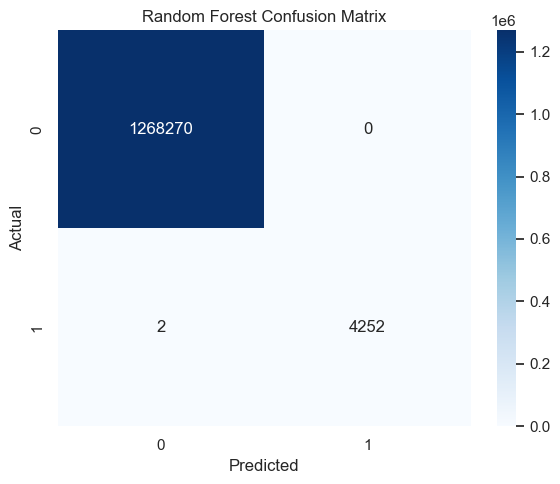

In [52]:
cm_rf = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [53]:
rf_pipeline = rf_model.named_steps["classifier"]
preprocessor_fitted = rf_model.named_steps["preprocessor"]

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_pipeline.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
8,num__amount_to_oldbalance_ratio,0.2972
6,num__origin_balance_drop,0.2645
2,num__oldbalanceOrg,0.0996
1,num__amount,0.0682
3,num__newbalanceOrig,0.0651
13,cat__type_TRANSFER,0.0489
7,num__destination_balance_change,0.0400
12,cat__type_PAYMENT,0.0380
5,num__newbalanceDest,0.0249
10,cat__type_CASH_OUT,0.0170


In [54]:
importance_df.head(20)

,Feature,Importance
8,num__amount_to_oldbalance_ratio,0.2972
6,num__origin_balance_drop,0.2645
2,num__oldbalanceOrg,0.0996
1,num__amount,0.0682
3,num__newbalanceOrig,0.0651
13,cat__type_TRANSFER,0.0489
7,num__destination_balance_change,0.0400
12,cat__type_PAYMENT,0.0380
5,num__newbalanceDest,0.0249
10,cat__type_CASH_OUT,0.0170


In [55]:
cm_rf

array([[1268270,       0],
       [      2,    4252]])

In [58]:
realtime_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
]

X_rt = df[realtime_features].copy()
y_rt = df["isFraud"].copy()

X_train_rt = X_rt.iloc[:split_point]
X_test_rt = X_rt.iloc[split_point:]

y_train_rt = y_rt.iloc[:split_point]
y_test_rt = y_rt.iloc[split_point:]


In [59]:
categorical_rt = ["type"]

numeric_rt = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
]

preprocessor_rt = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_rt
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_rt
        )
    ]
)

In [60]:
logistic_rt = Pipeline([
    ("preprocessor", preprocessor_rt),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000
        )
    )
])

logistic_rt.fit(
    X_train_rt,
    y_train_rt
)

logistic_rt_prob = logistic_rt.predict_proba(
    X_test_rt
)[:, 1]

logistic_rt_pred = (
    logistic_rt_prob >= 0.5
).astype(int)

In [61]:
rf_rt = Pipeline([
    ("preprocessor", preprocessor_rt),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=42
        )
    )
])

rf_rt.fit(
    X_train_rt,
    y_train_rt
)

rf_rt_prob = rf_rt.predict_proba(
    X_test_rt
)[:, 1]

rf_rt_pred = (
    rf_rt_prob >= 0.5
).astype(int)

In [62]:
logistic_rt_metrics = {
    "Accuracy": accuracy_score(
        y_test_rt,
        logistic_rt_pred
    ),
    "Precision": precision_score(
        y_test_rt,
        logistic_rt_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_rt,
        logistic_rt_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_rt,
        logistic_rt_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test_rt,
        logistic_rt_prob
    ),
    "PR_AUC": average_precision_score(
        y_test_rt,
        logistic_rt_prob
    )
}


rf_rt_metrics = {
    "Accuracy": accuracy_score(
        y_test_rt,
        rf_rt_pred
    ),
    "Precision": precision_score(
        y_test_rt,
        rf_rt_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test_rt,
        rf_rt_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test_rt,
        rf_rt_pred,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test_rt,
        rf_rt_prob
    ),
    "PR_AUC": average_precision_score(
        y_test_rt,
        rf_rt_prob
    )
}

In [63]:
model_comparison_rt = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        **logistic_rt_metrics
    },
    {
        "Model": "Random Forest",
        **rf_rt_metrics
    }
])

model_comparison_rt

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.9539,0.0578,0.8345,0.1081,0.9750,0.3302
1,Random Forest,0.9824,0.1127,0.6218,0.1908,0.9858,0.5000


In [64]:
precision_rt, recall_rt, thresholds_rt = precision_recall_curve(
    y_test_rt,
    rf_rt_prob
)

threshold_rt_df = pd.DataFrame({
    "threshold": thresholds_rt,
    "precision": precision_rt[:-1],
    "recall": recall_rt[:-1],
})

threshold_rt_df["f1"] = (
    2
    * threshold_rt_df["precision"]
    * threshold_rt_df["recall"]
    / (
        threshold_rt_df["precision"]
        + threshold_rt_df["recall"]
        + 1e-9
    )
)

threshold_rt_df.sort_values(
    "f1",
    ascending=False
).head(10)

,threshold,precision,recall,f1
97939,0.7193,0.7004,0.4095,0.5168
97938,0.7193,0.7002,0.4095,0.5168
97937,0.7193,0.6999,0.4095,0.5167
97940,0.7194,0.7003,0.4093,0.5166
97933,0.7191,0.6989,0.4097,0.5166
97936,0.7192,0.6993,0.4095,0.5165
97932,0.7191,0.6986,0.4097,0.5165
97935,0.7191,0.6990,0.4095,0.5165
97934,0.7191,0.6988,0.4095,0.5164
97931,0.7191,0.6980,0.4097,0.5164


In [65]:
best_rt_f1 = threshold_rt_df.loc[
    threshold_rt_df["f1"].idxmax()
]

best_rt_f1

threshold   0.7193
precision   0.7004
recall      0.4095
f1          0.5168
Name: 97939, dtype: float64

In [66]:
rt_precision_30 = threshold_rt_df[
    threshold_rt_df["precision"] >= 0.30
]

rt_precision_30.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall,f1
94104,0.6665,0.3000,0.5242,0.3816
94105,0.6665,0.3001,0.5242,0.3817
94107,0.6665,0.3000,0.5240,0.3815
94108,0.6665,0.3000,0.5240,0.3816
94109,0.6665,0.3001,0.5240,0.3816
94110,0.6666,0.3001,0.5240,0.3816
94111,0.6666,0.3002,0.5240,0.3817
94112,0.6666,0.3002,0.5240,0.3817
94113,0.6666,0.3003,0.5240,0.3818
94114,0.6666,0.3003,0.5240,0.3818


In [67]:
rt_precision_50 = threshold_rt_df[
    threshold_rt_df["precision"] >= 0.50
]

rt_precision_50.sort_values(
    "recall",
    ascending=False
).head(10)

,threshold,precision,recall,f1
96744,0.6981,0.5000,0.4652,0.4820
96745,0.6981,0.5001,0.4652,0.4820
96746,0.6981,0.5003,0.4652,0.4821
96747,0.6981,0.5004,0.4652,0.4822
96748,0.6981,0.5005,0.4652,0.4822
96749,0.6981,0.5004,0.4650,0.4820
96750,0.6981,0.5005,0.4650,0.4821
96751,0.6982,0.5006,0.4650,0.4821
96752,0.6982,0.5011,0.4650,0.4824
96753,0.6982,0.5013,0.4650,0.4824


In [68]:
candidate_thresholds_rt = [
    0.50,
    0.6665,
    0.7193
]

test_amount_rt = (
    df.iloc[split_point:]["amount"]
    .reset_index(drop=True)
)

financial_rt = []

for threshold in candidate_thresholds_rt:

    pred = (
        rf_rt_prob >= threshold
    ).astype(int)

    tp = (
        (y_test_rt.reset_index(drop=True) == 1)
        & (pred == 1)
    )

    fn = (
        (y_test_rt.reset_index(drop=True) == 1)
        & (pred == 0)
    )

    fp = (
        (y_test_rt.reset_index(drop=True) == 0)
        & (pred == 1)
    )

    detected_fraud_value = test_amount_rt[tp].sum()
    missed_fraud_value = test_amount_rt[fn].sum()
    flagged_value = test_amount_rt[pred == 1].sum()

    financial_rt.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_rt,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_rt,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_rt,
            pred,
            zero_division=0
        ),
        "TP": tp.sum(),
        "FP": fp.sum(),
        "FN": fn.sum(),
        "Detected_Fraud_Value": detected_fraud_value,
        "Missed_Fraud_Value": missed_fraud_value,
        "Flagged_Transaction_Value": flagged_value
    })

financial_rt_df = pd.DataFrame(financial_rt)

financial_rt_df

,Threshold,Precision,Recall,F1,TP,FP,FN,Detected_Fraud_Value,Missed_Fraud_Value,Flagged_Transaction_Value
0,0.5000,0.1127,0.6218,0.1908,2645,20822,1609,"6,335,396,977.6400","349,336,268.1800","10,050,756,270.8500"
1,0.6665,0.3000,0.5240,0.3816,2229,5200,2025,"6,159,373,498.3400","525,359,747.4800","7,132,689,230.7300"
2,0.7193,0.7002,0.4095,0.5168,1742,746,2512,"5,977,298,378.2900","707,434,867.5300","6,156,718,317.4500"


### Threshold Optimization

The real-time Random Forest was evaluated at multiple probability thresholds
to understand the operational trade-off between fraud detection and
investigation workload.

At the default threshold of 0.50, the model achieved 62.18% recall but
generated 20,822 false positives and flagged transactions worth approximately
10.05B.

Increasing the threshold to 0.7193 increased precision to 70.02% and reduced
false positives to only 746, while still capturing approximately 5.98B in
fraudulent transaction value.

This demonstrates that fraud detection is not a single-metric optimization
problem. The appropriate threshold depends on the business trade-off between
missed fraud exposure and the operational cost of investigating false alerts.

For the dashboard's high-confidence review scenario, a threshold of 0.7193
is used as the default operating point.

In [69]:
# ==========================================
# RANDOM FOREST FEATURE IMPORTANCE
# ==========================================

rf_rt_classifier = rf_rt.named_steps["classifier"]
rf_rt_preprocessor = rf_rt.named_steps["preprocessor"]

feature_names_rt = (
    rf_rt_preprocessor
    .get_feature_names_out()
)

importance_rt = pd.DataFrame({
    "Feature": feature_names_rt,
    "Importance": rf_rt_classifier.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

importance_rt.head(15)

,Feature,Importance
0,num__oldbalanceOrg,0.3027
1,num__amount,0.2290
2,cat__type_TRANSFER,0.1003
3,cat__type_CASH_IN,0.0980
4,cat__type_PAYMENT,0.0927
5,num__oldbalanceDest,0.0793
6,cat__type_CASH_OUT,0.0720
7,num__step,0.0253
8,cat__type_DEBIT,0.0008


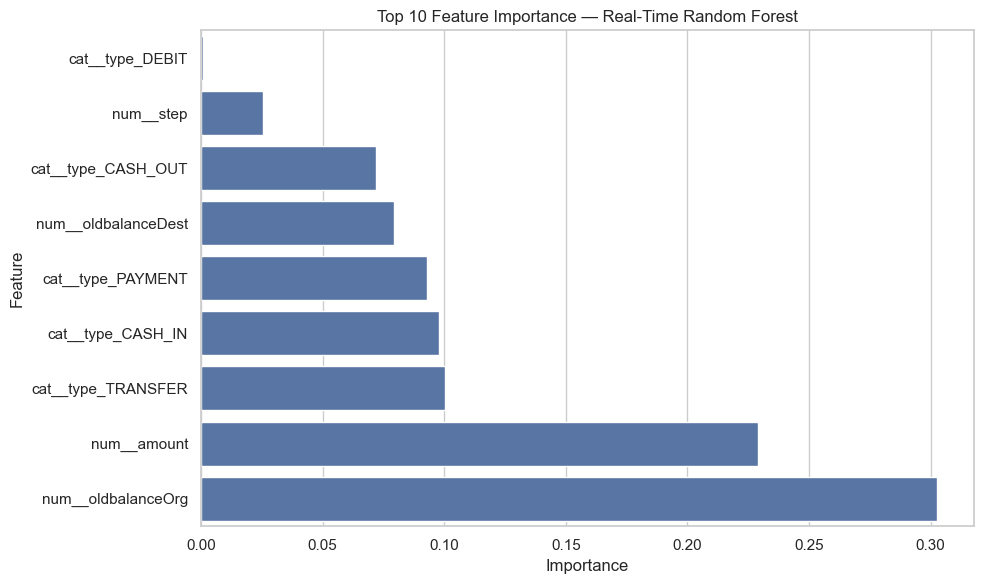

In [70]:
plt.figure(figsize=(10, 6))

top_features = importance_rt.head(10).sort_values(
    "Importance",
    ascending=True
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importance — Real-Time Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [71]:
def assign_risk_level(probability, threshold=0.7193):

    if probability >= threshold:
        return "CRITICAL"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.30:
        return "MEDIUM"

    else:
        return "LOW"

In [72]:
for p in [0.12, 0.35, 0.62, 0.80, 0.97]:
    print(
        p,
        "→",
        assign_risk_level(p)
    )

0.12 → LOW
0.35 → MEDIUM
0.62 → HIGH
0.8 → CRITICAL
0.97 → CRITICAL


In [73]:
risk_results = X_test_rt.copy()

risk_results["actual_fraud"] = (
    y_test_rt.values
)

risk_results["fraud_probability"] = (
    rf_rt_prob
)

risk_results["risk_level"] = (
    risk_results["fraud_probability"]
    .apply(assign_risk_level)
)

risk_results.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,actual_fraud,fraud_probability,risk_level
5090096,355,CASH_OUT,"129,493.8200","496,957.0000",0.0000,0,0.1353,LOW
5090097,355,PAYMENT,"5,787.6300","513,408.0000",0.0000,0,0.0000,LOW
5090098,355,CASH_OUT,"172,499.2400","150,346.0000",0.0000,0,0.6738,HIGH
5090099,355,CASH_OUT,"377,391.0100","30,759.0000","1,409,725.3900",0,0.0309,LOW
5090100,355,PAYMENT,"12,469.5000",315.0000,0.0000,0,0.0000,LOW


In [74]:
risk_distribution = (
    risk_results["risk_level"]
    .value_counts()
    .reindex(
        ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0
    )
    .reset_index()
)

risk_distribution.columns = [
    "Risk_Level",
    "Transactions"
]

risk_distribution

,Risk_Level,Transactions
0,LOW,1212665
1,MEDIUM,36392
2,HIGH,20979
3,CRITICAL,2488


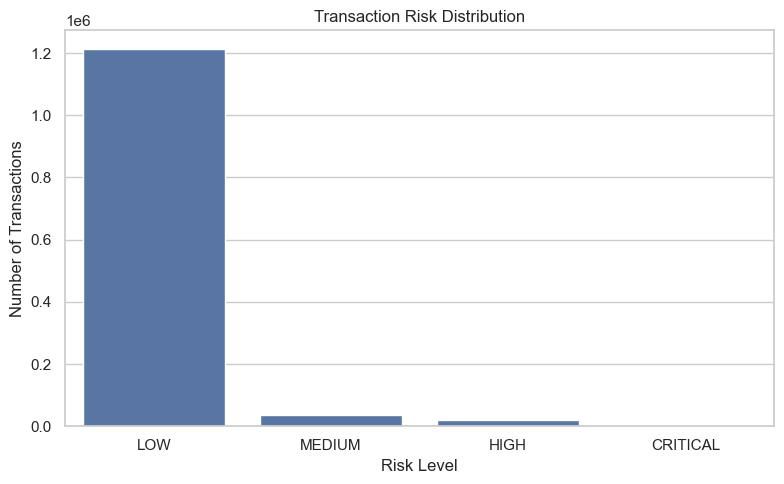

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=risk_distribution,
    x="Risk_Level",
    y="Transactions"
)

plt.title("Transaction Risk Distribution")

plt.xlabel("Risk Level")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [76]:
risk_results["transaction_amount"] = (
    df.iloc[split_point:]["amount"]
    .reset_index(drop=True)
)

In [77]:
risk_exposure = (
    risk_results
    .groupby("risk_level")
    .agg(
        Transactions=("transaction_amount", "count"),
        Transaction_Value=("transaction_amount", "sum"),
        Average_Amount=("transaction_amount", "mean")
    )
    .reindex(
        ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
    )
    .reset_index()
)

risk_exposure

,risk_level,Transactions,Transaction_Value,Average_Amount
0,LOW,0,0.0000,NaN
1,MEDIUM,0,0.0000,NaN
2,HIGH,0,0.0000,NaN
3,CRITICAL,0,0.0000,NaN


In [78]:
investigation_queue = (
    risk_results[
        risk_results["fraud_probability"] >= 0.7193
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
)

investigation_queue.head(20)

,step,type,amount,oldbalanceOrg,oldbalanceDest,actual_fraud,fraud_probability,risk_level,transaction_amount
6202287,582,CASH_OUT,"6,106,149.5200","6,106,149.5200","2,003,487.0500",1,0.9847,CRITICAL,NaN
5563506,386,CASH_OUT,"10,000,000.0000","10,000,000.0000","1,950,323.2800",1,0.9847,CRITICAL,NaN
6259957,606,CASH_OUT,"3,973,479.4400","3,973,479.4400","2,036,641.3400",1,0.9847,CRITICAL,NaN
6308250,685,CASH_OUT,"6,295,010.2800","6,295,010.2800","2,848,244.0800",1,0.9847,CRITICAL,NaN
6351136,698,CASH_OUT,"9,097,679.7500","9,097,679.7500","2,958,471.2700",1,0.9847,CRITICAL,NaN
6361722,718,CASH_OUT,"10,000,000.0000","10,000,000.0000","2,517,892.1800",1,0.9847,CRITICAL,NaN
5563776,391,CASH_OUT,"4,559,921.5600","4,559,921.5600","2,781,040.9500",1,0.9847,CRITICAL,NaN
6362507,734,CASH_OUT,"10,000,000.0000","10,000,000.0000","2,571,402.2500",1,0.9847,CRITICAL,NaN
6064977,506,CASH_OUT,"10,000,000.0000","10,000,000.0000","1,920,358.2400",1,0.9847,CRITICAL,NaN
6018734,452,CASH_OUT,"7,578,130.4500","7,578,130.4500","1,922,837.2500",1,0.9847,CRITICAL,NaN


In [79]:
print(
    "High-confidence alerts:",
    len(investigation_queue)
)

print(
    "Alert transaction value:",
    f"{investigation_queue['transaction_amount'].sum():,.2f}"
)

High-confidence alerts: 2488
Alert transaction value: 0.00


In [80]:
risk_summary = {
    "total_transactions": len(risk_results),

    "high_confidence_alerts": len(
        investigation_queue
    ),

    "alert_value": investigation_queue[
        "transaction_amount"
    ].sum(),

    "avg_alert_probability": investigation_queue[
        "fraud_probability"
    ].mean(),

    "threshold": 0.7193
}

risk_summary

{'total_transactions': 1272524,
 'high_confidence_alerts': 2488,
 'alert_value': np.float64(0.0),
 'avg_alert_probability': np.float64(0.8385829197709599),
 'threshold': 0.7193}

## Feature Importance & Risk Scoring

The final real-time Random Forest model was analyzed using feature
importance to understand which transaction characteristics contributed most
to fraud-risk prediction.

The model probability was then translated into operational risk levels:

- **LOW** — low predicted fraud risk
- **MEDIUM** — moderate risk requiring additional monitoring
- **HIGH** — elevated risk
- **CRITICAL** — probability above the selected high-confidence operating
  threshold of **0.7193**

The threshold was selected through precision-recall analysis and financial
impact evaluation.

At the selected operating point, the model achieved approximately **70.02%
precision**, **40.95% recall**, and **51.68% F1-score**.

This threshold substantially reduced false positives compared with the
default 0.50 threshold, making it more suitable for a high-confidence fraud
investigation queue.

In [83]:
# ==========================================
# FINAL RISK SCORING TABLE
# ==========================================

risk_results = X_test_rt.reset_index(drop=True).copy()

risk_results["actual_fraud"] = (
    y_test_rt.reset_index(drop=True).to_numpy()
)

risk_results["fraud_probability"] = (
    rf_rt_prob
)

risk_results["transaction_amount"] = (
    df.iloc[split_point:]["amount"]
    .reset_index(drop=True)
    .to_numpy()
)

In [84]:
def assign_risk_level(probability, threshold=0.7193):

    if probability >= threshold:
        return "CRITICAL"

    elif probability >= 0.50:
        return "HIGH"

    elif probability >= 0.30:
        return "MEDIUM"

    else:
        return "LOW"

In [85]:
risk_results["risk_level"] = (
    risk_results["fraud_probability"]
    .apply(assign_risk_level)
)

In [86]:
risk_results.head()

,step,type,amount,oldbalanceOrg,oldbalanceDest,actual_fraud,fraud_probability,transaction_amount,risk_level
0,355,CASH_OUT,"129,493.8200","496,957.0000",0.0000,0,0.1353,"129,493.8200",LOW
1,355,PAYMENT,"5,787.6300","513,408.0000",0.0000,0,0.0000,"5,787.6300",LOW
2,355,CASH_OUT,"172,499.2400","150,346.0000",0.0000,0,0.6738,"172,499.2400",HIGH
3,355,CASH_OUT,"377,391.0100","30,759.0000","1,409,725.3900",0,0.0309,"377,391.0100",LOW
4,355,PAYMENT,"12,469.5000",315.0000,0.0000,0,0.0000,"12,469.5000",LOW


In [87]:
risk_results["risk_level"].value_counts()

risk_level
LOW         1212665
MEDIUM        36392
HIGH          20979
CRITICAL       2488
Name: count, dtype: int64

In [88]:
risk_exposure = (
    risk_results
    .groupby("risk_level", observed=False)
    .agg(
        Transactions=("transaction_amount", "count"),
        Transaction_Value=("transaction_amount", "sum"),
        Average_Amount=("transaction_amount", "mean")
    )
    .reindex(
        ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
        fill_value=0
    )
    .reset_index()
)

risk_exposure

,risk_level,Transactions,Transaction_Value,Average_Amount
0,LOW,1212665,"206,104,238,936.3900","169,959.7489"
1,MEDIUM,36392,"5,127,957,496.2000","140,908.9222"
2,HIGH,20979,"3,894,037,953.4000","185,615.9947"
3,CRITICAL,2488,"6,156,718,317.4500","2,474,565.2401"


In [89]:
FINAL_THRESHOLD = 0.7193

investigation_queue = (
    risk_results[
        risk_results["fraud_probability"] >= FINAL_THRESHOLD
    ]
    .sort_values(
        "fraud_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "High-confidence alerts:",
    len(investigation_queue)
)

print(
    "Alert transaction value:",
    f"{investigation_queue['transaction_amount'].sum():,.2f}"
)

High-confidence alerts: 2488
Alert transaction value: 6,156,718,317.45


In [90]:
risk_summary = {
    "total_transactions": len(risk_results),
    "high_confidence_alerts": len(investigation_queue),
    "alert_value": investigation_queue[
        "transaction_amount"
    ].sum(),
    "avg_alert_probability": investigation_queue[
        "fraud_probability"
    ].mean(),
    "threshold": FINAL_THRESHOLD
}

risk_summary

{'total_transactions': 1272524,
 'high_confidence_alerts': 2488,
 'alert_value': np.float64(6156718317.45),
 'avg_alert_probability': np.float64(0.8385829197709599),
 'threshold': 0.7193}

## Risk Distribution & Financial Exposure

The real-time Random Forest model was converted into four operational risk
levels:

- **LOW:** predicted probability below 0.30
- **MEDIUM:** 0.30–0.49
- **HIGH:** 0.50–0.7192
- **CRITICAL:** ≥ 0.7193

The resulting risk distribution shows that most transactions remain in the
LOW-risk category.

However, the CRITICAL category contains only **2,488 transactions** while
representing approximately **6.16B in transaction value**.

The average transaction value within the CRITICAL category is approximately
**2.47M**, substantially higher than the LOW-risk average of approximately
**170K**.

### Business Insight

This demonstrates the value of risk scoring beyond binary fraud
classification.

Rather than treating every flagged transaction equally, the system can help
fraud investigators prioritize a relatively small set of high-confidence,
high-value transactions.

The dashboard therefore focuses on:

> **Risk probability → Risk level → Investigation priority → Financial exposure**